In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_excel("data1319.xlsx")

/Users/charlesyamamura/ls/envs/mlenv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [4]:
# -----------------------------
# 2. Temporal split
# -----------------------------
train_df = df[df['year'] <= 2018].copy()
test_df  = df[df['year'] == 2019].copy()

In [5]:
y_train = train_df['share'].values
y_test  = test_df['share'].values

In [6]:
exclude_cols = ["share", "mo", "year", "model"]
X_train_raw = train_df.drop(columns=exclude_cols)
X_test_raw  = test_df.drop(columns=exclude_cols)

In [7]:
# -----------------------------
# 3. Encoding (Label Encoding for all models)
# -----------------------------
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

In [8]:
for col in X_train.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])

In [9]:
# -----------------------------
# 4. Scaling (Specifically for Neural Network)
# -----------------------------
input_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [10]:
X_train_scaled = input_scaler.fit_transform(X_train)
X_test_scaled  = input_scaler.transform(X_test)

In [11]:
# Reshape y for the scaler
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled  = target_scaler.transform(y_test.reshape(-1, 1))

In [12]:
# Convert to tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)

In [13]:
# -----------------------------
# 5. Tree-Based Models (XGB & RF)
# -----------------------------
tscv = TimeSeriesSplit(n_splits=4)

In [14]:
# --- XGBoost ---
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid={"n_estimators": [300, 500], "max_depth": [3, 5], "learning_rate": [0.01, 0.05]},
    cv=tscv, scoring="r2", n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

In [15]:
# --- Random Forest ---
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid={"n_estimators": [200, 400], "max_depth": [None, 10], "max_features": ["sqrt"]},
    cv=tscv, scoring="r2", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

In [16]:
# -----------------------------
# 6. Neural Network (MLP)
# -----------------------------
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size=8, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )
    def forward(self, x): return self.net(x)

In [17]:
input_size = X_train_t.shape[1]
nn_model = SimpleMLP(input_size=input_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-4)

In [18]:
# Training Loop
num_epochs = 150
batch_size = 10
for epoch in range(num_epochs):
    nn_model.train()
    permutation = torch.randperm(X_train_t.size(0))
    for i in range(0, X_train_t.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        optimizer.zero_grad()
        loss = criterion(nn_model(X_train_t[indices]), y_train_t[indices])
        loss.backward()
        optimizer.step()

In [19]:
# -----------------------------
# 7. Unified Evaluation
# -----------------------------
def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [20]:
results = []

In [21]:
# Eval XGB train
results.append(get_metrics("XGB train", y_train, xgb_best.predict(X_train)))

In [22]:
# Eval XGB test
results.append(get_metrics("XGB test", y_test, xgb_best.predict(X_test)))

In [23]:
# Eval RF train
results.append(get_metrics("RF train", y_train, rf_best.predict(X_train)))

In [24]:
# Eval RF test
results.append(get_metrics("RF test", y_test, rf_best.predict(X_test)))

In [25]:
# Eval NN train
nn_model.eval()
with torch.no_grad():
    nn_preds_scaled = nn_model(X_train_t).numpy()
    nn_preds = target_scaler.inverse_transform(nn_preds_scaled).flatten()
results.append(get_metrics("NN train", y_train, nn_preds))

In [26]:
# Eval NN test
nn_model.eval()
with torch.no_grad():
    nn_preds_scaled = nn_model(X_test_t).numpy()
    nn_preds = target_scaler.inverse_transform(nn_preds_scaled).flatten()
results.append(get_metrics("NN test", y_test, nn_preds))

In [27]:
# -----------------------------
# 8. Final Comparison
# -----------------------------
results_df = pd.DataFrame(results)
print("\nFinal Train/Test Performance Comparison:")
print(results_df.sort_values(by="R2", ascending=False).to_string(index=False))


Final Train/Test Performance Comparison:
    Model       R2     RMSE      MAE
 RF train 0.900322 0.246288 0.161442
 NN train 0.878428 0.271995 0.182926
XGB train 0.865990 0.285570 0.203532
  RF test 0.765639 0.401601 0.302838
 XGB test 0.637489 0.499474 0.363754
  NN test 0.430817 0.625861 0.410594


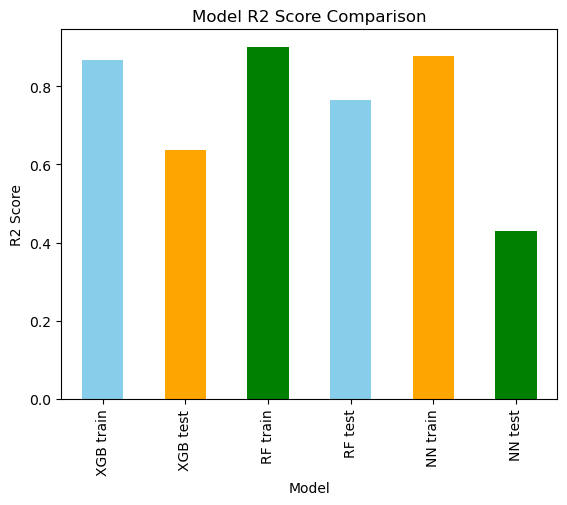

In [28]:
# Optional: Plotting results
results_df.set_index("Model")["R2"].plot(kind='bar', color=['skyblue', 'orange', 'green'])
plt.title("Model R2 Score Comparison")
plt.ylabel("R2 Score")
plt.show()